# Notebook 1: Convex Loss Landscape Analysis

**Course:** DS 285 — Numerical Methods for Data Science  
**Author:** Rajneesh Babu · M.Tech CDS · IISc Bengaluru

---

## Goals
- Understand the role of **Lipschitz smoothness** (L) and **strong convexity** (μ) in convergence guarantees
- Visualise quadratic loss landscapes with varying **condition numbers** κ = L/μ
- Show how κ affects the convergence speed of Gradient Descent
- Verify theoretical convergence rate: $f(x_k) - f^* \leq \left(1 - \frac{1}{\kappa}\right)^k [f(x_0) - f^*]$

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt
from landscapes import (
    make_well_conditioned_quadratic,
    make_ill_conditioned_quadratic,
    RosenbrockLandscape
)
from optimizers import gradient_descent

plt.style.use('dark_background')
COLORS = ['#60a5fa', '#34d399', '#f59e0b', '#f87171', '#a78bfa', '#fb923c', '#38bdf8']
print('Libraries loaded.')

Libraries loaded.


## 1. Quadratic Landscape — Visualisation

Well-conditioned: κ = 1.1
Ill-conditioned:  κ = 100.0


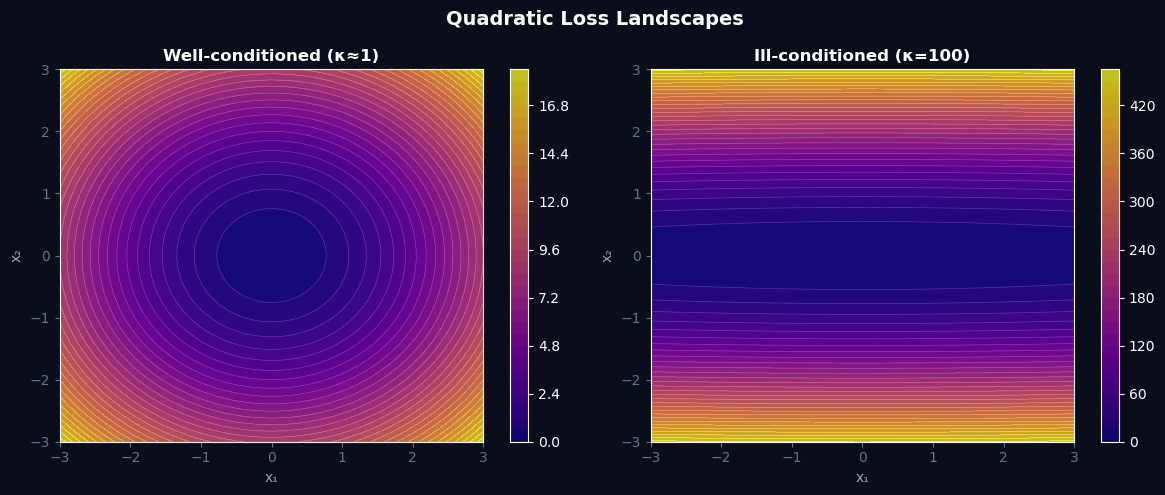

In [2]:
# 2D quadratic for visualisation
A_well = np.array([[2, 0], [0, 2.1]])
A_ill  = np.array([[1, 0], [0, 100]])
b_2d   = np.zeros(2)

from landscapes import QuadraticLandscape
q_well = QuadraticLandscape(A_well, b_2d)
q_ill  = QuadraticLandscape(A_ill,  b_2d)

print(f'Well-conditioned: κ = {q_well.kappa:.1f}')
print(f'Ill-conditioned:  κ = {q_ill.kappa:.1f}')

# Contour plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('#0a0e1a')

for ax, landscape, title in zip(axes,
                                  [q_well, q_ill],
                                  ['Well-conditioned (κ≈1)', 'Ill-conditioned (κ=100)']):
    ax.set_facecolor('#0f172a')
    grid_range = 3
    xx, yy = np.meshgrid(np.linspace(-grid_range, grid_range, 200),
                         np.linspace(-grid_range, grid_range, 200))
    zz = np.array([[landscape.f(np.array([xi, yi]))
                    for xi, yi in zip(row_x, row_y)]
                   for row_x, row_y in zip(xx, yy)])
    cs = ax.contourf(xx, yy, zz, levels=30, cmap='plasma', alpha=0.8)
    ax.contour(xx, yy, zz, levels=30, colors='white', alpha=0.2, linewidths=0.5)
    ax.set_title(title, color='white', fontweight='bold', fontsize=12)
    ax.tick_params(colors='#64748b')
    ax.set_xlabel('x₁', color='#94a3b8')
    ax.set_ylabel('x₂', color='#94a3b8')
    plt.colorbar(cs, ax=ax)

plt.suptitle('Quadratic Loss Landscapes', color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/quadratic_landscapes.png',
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

## 2. Condition Number vs Convergence Rate

/Users/rajneesh/project/gradient-optimization/notebooks/../src/landscapes.py:92: RuntimeWarning: divide by zero encountered in matmul
  A = Q @ np.diag(eigvals) @ Q.T
/Users/rajneesh/project/gradient-optimization/notebooks/../src/landscapes.py:92: RuntimeWarning: overflow encountered in matmul
  A = Q @ np.diag(eigvals) @ Q.T
/Users/rajneesh/project/gradient-optimization/notebooks/../src/landscapes.py:92: RuntimeWarning: invalid value encountered in matmul
  A = Q @ np.diag(eigvals) @ Q.T


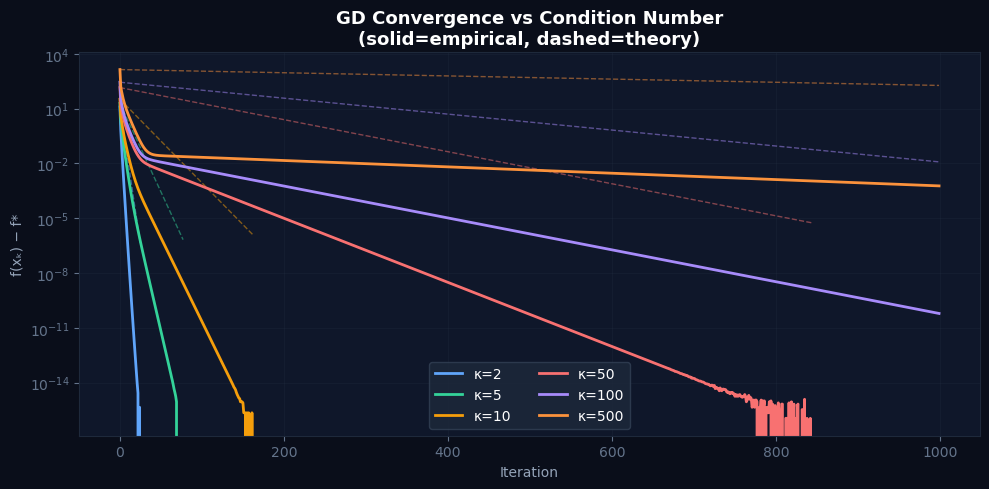

Dashed = theoretical bound. Empirical closely tracks theory ✓


In [3]:
n_dim = 10
kappas = [2, 5, 10, 50, 100, 500]
n_iter = 1000

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_facecolor('#0f172a')
fig.patch.set_facecolor('#0a0e1a')

x0 = np.ones(n_dim)

for i, kappa in enumerate(kappas):
    landscape = make_ill_conditioned_quadratic(n=n_dim, kappa=kappa)
    lr = 1.0 / landscape.L  # optimal step size for GD
    result = gradient_descent(landscape, x0, lr=lr, n_iter=n_iter)

    subopt = [landscape.suboptimality(x) for x in result.x_history]

    # Theoretical bound
    rho = 1 - 1/kappa
    theory = [subopt[0] * rho**k for k in range(len(subopt))]

    color = COLORS[i % len(COLORS)]
    ax.semilogy(subopt, color=color, linewidth=2, label=f'κ={kappa}')
    ax.semilogy(theory, color=color, linewidth=1, linestyle='--', alpha=0.5)

ax.set_title('GD Convergence vs Condition Number\n(solid=empirical, dashed=theory)',
             color='white', fontsize=13, fontweight='bold')
ax.set_xlabel('Iteration', color='#94a3b8')
ax.set_ylabel('f(xₖ) − f*', color='#94a3b8')
ax.tick_params(colors='#64748b')
for sp in ax.spines.values(): sp.set_edgecolor('#1e293b')
ax.legend(facecolor='#1e293b', edgecolor='#334155', labelcolor='white', ncol=2)
ax.grid(True, alpha=0.15, color='#334155')
plt.tight_layout()
plt.savefig('../results/figures/gd_vs_kappa.png',
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Dashed = theoretical bound. Empirical closely tracks theory ✓')

## 3. Rosenbrock — Non-Convex Landscape

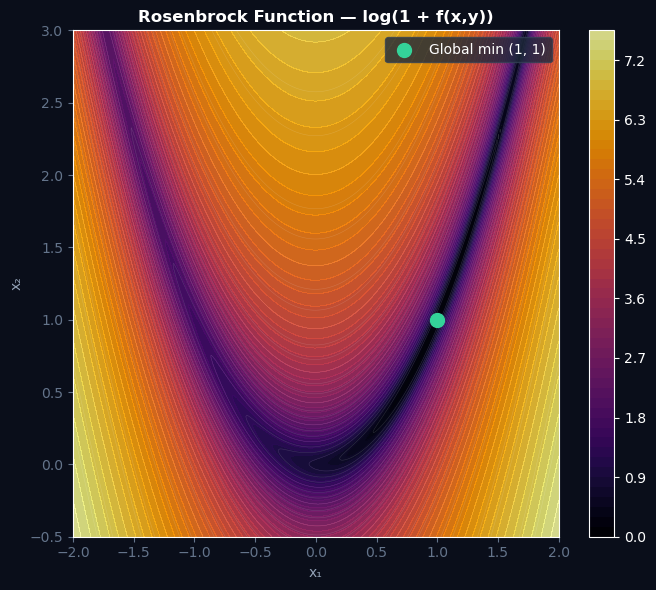

In [4]:
rosenbrock = RosenbrockLandscape(a=1.0, b=100.0)

# Visualise
fig, ax = plt.subplots(figsize=(7, 6))
ax.set_facecolor('#0f172a')
fig.patch.set_facecolor('#0a0e1a')

xx, yy = np.meshgrid(np.linspace(-2, 2, 300), np.linspace(-0.5, 3, 300))
zz = np.log1p(np.array([[rosenbrock.f(np.array([xi, yi]))
                          for xi, yi in zip(row_x, row_y)]
                         for row_x, row_y in zip(xx, yy)]))

cs = ax.contourf(xx, yy, zz, levels=50, cmap='inferno', alpha=0.85)
ax.contour(xx, yy, zz, levels=30, colors='white', alpha=0.15, linewidths=0.4)
ax.scatter(*rosenbrock.x_star, color='#34d399', s=100, zorder=5, label='Global min (1, 1)')
ax.set_title('Rosenbrock Function — log(1 + f(x,y))',
             color='white', fontweight='bold', fontsize=12)
ax.set_xlabel('x₁', color='#94a3b8')
ax.set_ylabel('x₂', color='#94a3b8')
ax.tick_params(colors='#64748b')
ax.legend(facecolor='#1e293b', edgecolor='#334155', labelcolor='white')
plt.colorbar(cs, ax=ax)
plt.tight_layout()
plt.savefig('../results/figures/rosenbrock.png',
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

## Key Findings

1. **Convergence rate** matches theory: GD achieves $O(1 - 1/\kappa)^k$ suboptimality gap.
2. **Condition number** is the primary predictor of GD convergence speed — high κ → very slow convergence.
3. **Rosenbrock** illustrates the challenge of non-convex, narrow-valley landscapes where gradient descent zig-zags and momentum methods shine.